In [1]:
!pip install pandas seaborn scikit-learn

# Домашнее задание про практике 2

- Провести разведочный анализ EDA (описать полученный результат). Тут важно, влияет ли X[i] на Y (примеры в практике 2)
- Описать полученный результат относительно анализа целевой перменной и зависимой (см. практика 2)
- Подобороться с пропусками в данных (при наличии в датасете). Объяснить способ выборка борьбы с пропуском
- Обучить модель линейной регресии на всей выборке X, y. Вывести метрики
- Сделать train_test_split и обучить на обучающей выборке. Предсказать результат на обучающей и тестовой выборках. Вывести метрики, объяснить полученный результат

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
PATH_TO_FILE: str = '/content/heart.csv'
df = pd.read_csv(PATH_TO_FILE)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
# преобразовать категориальные признаки в category
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
for c in cat_cols:
    df[c] = df[c].astype('category')

int_cols = ['age', 'trestbps', 'chol']
for c in int_cols:
    df[c] = df[c].astype('int')

float_cols = ['thalach', 'oldpeak']
for c in float_cols:
    df[c] = df[c].astype('float')

In [8]:
# выбрать целевую переменную и разделить на X, y
# целевая переменная - числовой непрерывный признак

y = df['oldpeak']
X = df.drop('oldpeak', axis=1)


## EDA (разведочный анализ относительно целевой переменной)

в этом же блоке побороться с пропусками, важно сделать именно после разведочного анализа
- Y и категориальные
- Y и числовые
- Описать все полученные результаты в своем блоке

- Отобрать признаки для дальнейшего анализа, записать в ```best_features```

count    303.000000
mean       1.039604
std        1.161075
min        0.000000
25%        0.000000
50%        0.800000
75%        1.600000
max        6.200000
Name: oldpeak, dtype: float64


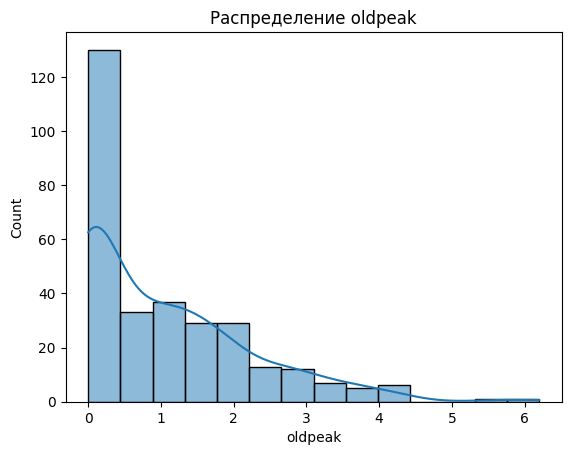

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [10]:
# быстрый обзор целевой
print(df['oldpeak'].describe())
sns.histplot(df['oldpeak'], kde=True)
plt.title('Распределение oldpeak'); plt.show()

# проверка пропусков
print(df.isna().sum())

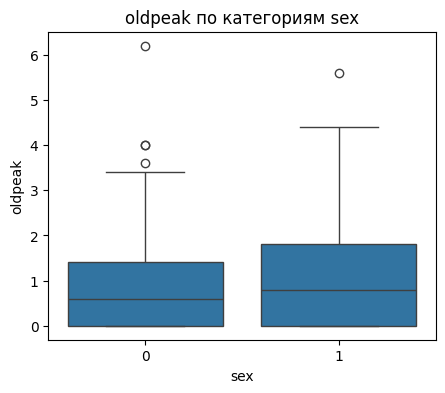

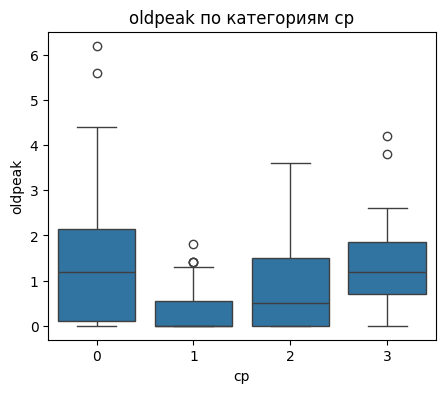

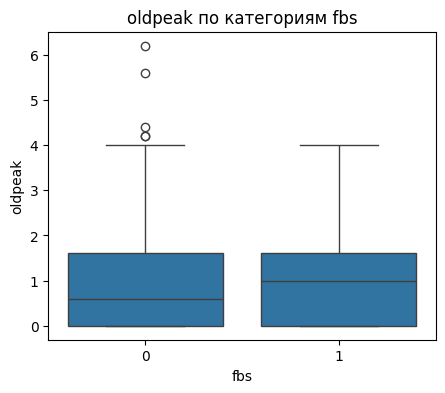

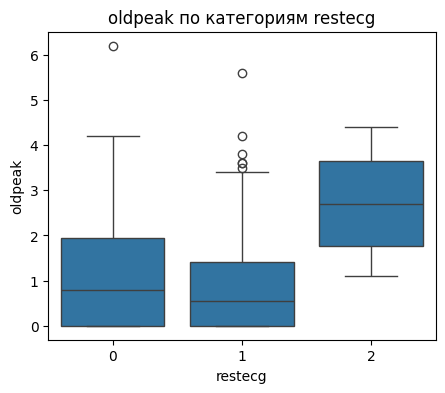

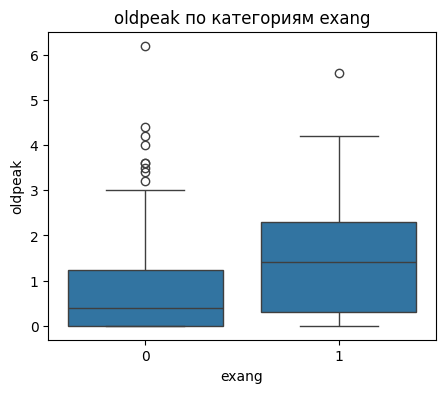

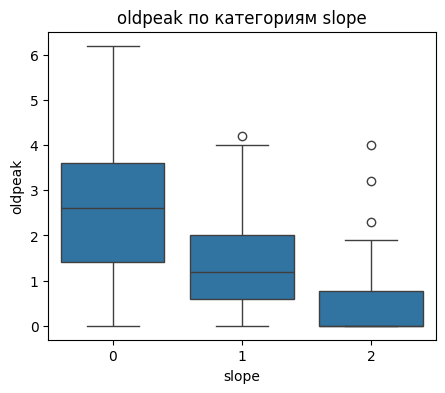

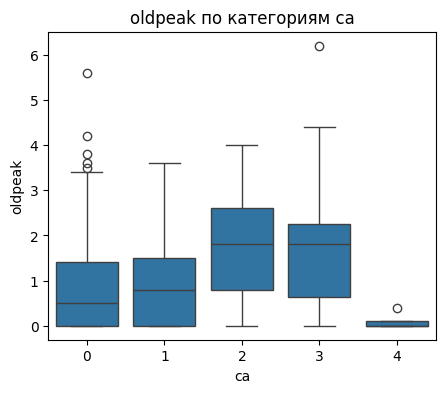

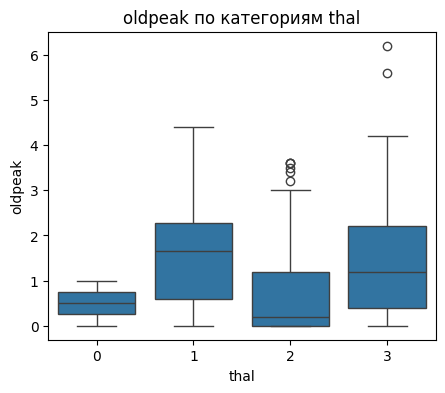

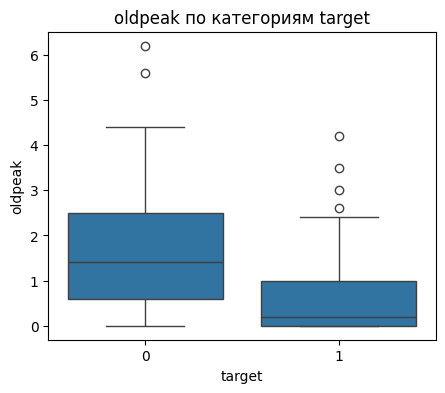

In [12]:
#Категориальные признаки
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

for col in cat_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(x=col, y='oldpeak', data=df)
    plt.title(f'oldpeak по категориям {col}')
    plt.show()

Смотрим, где медиана oldpeak выше: такие категории сильнее связаны с ростом целевой (часто exang=1, некоторые типы cp, высокий ca)

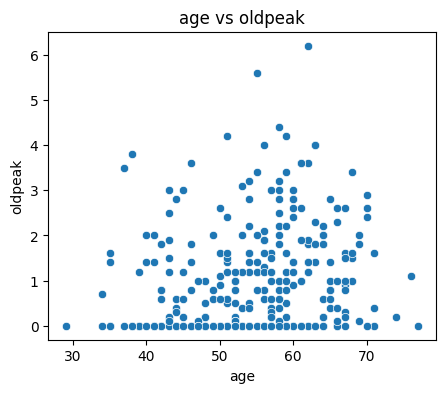

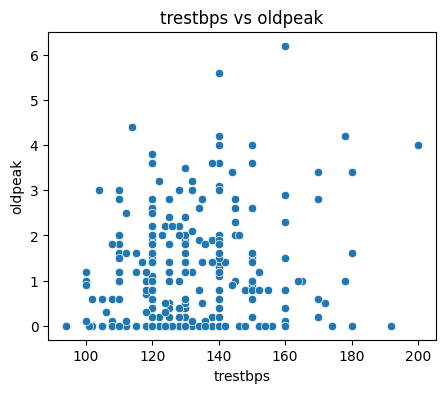

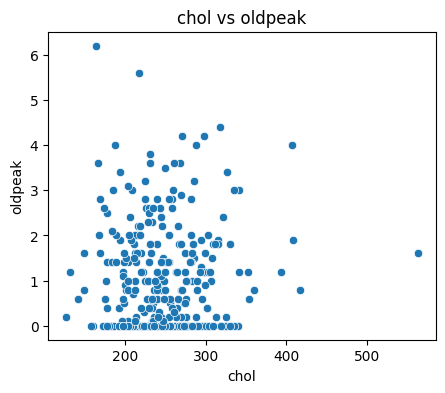

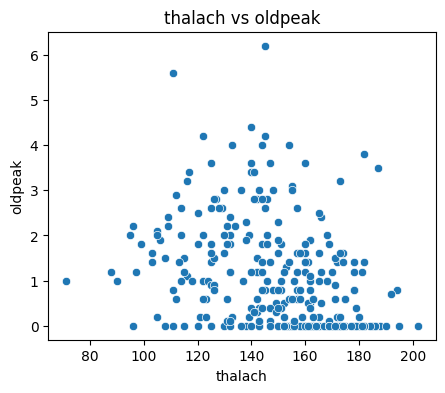

thalach    -0.344187
chol        0.053952
trestbps    0.193216
age         0.210013
oldpeak     1.000000
Name: oldpeak, dtype: float64


In [13]:
#Числовые признаки
num_cols = ['age', 'trestbps', 'chol', 'thalach']

for col in num_cols:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=col, y='oldpeak', data=df)
    plt.title(f'{col} vs oldpeak')
    plt.show()

# при желании – корреляции с целевой
print(df[num_cols + ['oldpeak']].corr()['oldpeak'].sort_values())

Обычно oldpeak умеренно отрицательно связан с thalach (чем выше депрессия ST, тем ниже макс. пульс) и слабо положительно с возрастом

In [ ]:
categorial_features = [] # перечислить названия колонок с категориальными фичами
numeric_features = [] # перечислить названия колонок с категориальными фичами
best_features = categorial_features + numeric_features

## Моделирование

**Общая задача:**
Сравнить несколько вариантов линейной регрессии на датасете (с предобработкой признаков: стандартизация числовых, OneHot/Label для категориальных).

**предобработка**
- Категориальные признаки преобразовать с помощью OneHotEncoder (если признак является типом **bool** по логике можно интерпретировать как (true, false) То можно LabelEncoder)
- Числовые признаки записать в `X_scaled` и провести стандартизацию с помощью `StandardScaler`. Желательно без категориальных признаков


---
**Метрики**: (MAE, MAPE, R², MSE, RMSE)

---

**Модель 1.**

- Использовать **все признаки (кроме y)**.
- Обучить на **всей выборке** (без разделения).
- Сделать предсказания на этой же выборке.
- Вывести метрики и интерпретировать.
- Построить график коэффициентов (model.coef\_ vs X\_scaled.columns) и интерпретировать.

---

**Модель 2.**

- Использовать **все признаки**.
- Сделать `train_test_split`.
- Обучить на `X_train`, предсказать на `X_train` и `X_test`.
- Вывести метрики для обучающей и тестовой выборки, интерпретировать.
- Визуализировать коэффициенты и интерпретировать.

---

**Модель 3.**

- Использовать только **best\_features** (отобранные признаки).
- Обучить на **всей выборке**.
- Предсказать на всей выборке.
- Вывести метрики качества и интерпретировать.
- Визуализировать коэффициенты и интерпретировать.

---

**Модель 4.**

- Использовать **best\_features**.
- Сделать `train_test_split`.
- Обучить на `X_train`, предсказать на `X_train` и `X_test`.
- Вывести метрики качества для обучающей и тестовой выборки, интерпретировать.
- Визуализировать коэффициенты и интерпретировать.

---

P.S.
- Важно не забывать о стандартизации и разделении категориальных признаков на отдельные олонки
- Все примеры есть в практике 2


P.S.S
Старайтесь делать собственные предположения, ChatGPT задачу решит, но вы не добьетесь понимания полученных результатов

---
В результате должно получиться 4 модели

- первые две на всех колонках (фичах)
- последующие на отобранных фичах (колонках)

### Преобразование категориальных

In [15]:
import numpy as np

# целевая переменная
y = df['oldpeak']

# признаки
X = df.drop('oldpeak', axis=1)

categorial_features = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']
numeric_features     = ['age','trestbps','chol','thalach']   # oldpeak уже в y


In [16]:
from sklearn.preprocessing import OneHotEncoder

# OneHot для всех категорий (они уже числовые кодами, но логически — категории)
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' уменьшит мультиколлинеарность
X_cat = encoder.fit_transform(X[categorial_features])

cat_cols_ohe = encoder.get_feature_names_out(categorial_features)
X_cat = pd.DataFrame(X_cat, columns=cat_cols_ohe, index=X.index)

# убираем старые категориальные и добавляем закодированные
X_num = X[numeric_features].copy()
X_encoded = pd.concat([X_num, X_cat], axis=1)

### Преобразование числовых

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# стандартизируем только исходные числовые признаки
X_num_scaled = scaler.fit_transform(X_num)
X_num_scaled = pd.DataFrame(X_num_scaled, columns=numeric_features, index=X.index)

# финальная матрица признаков: scaled числовые + OHE категории
X_final = pd.concat([X_num_scaled, X_cat], axis=1)

X_scaled = X_final.values     # так и будем называть для модели
feature_names = X_final.columns


### Модель 1

In [18]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_scaled, y)          # обучение на всей выборке
y_pred1 = model1.predict(X_scaled)

### Разделение на обучающую, тестовую

In [19]:
from sklearn.model_selection import train_test_split

# X_scaled = X_final.values  # как было выше
# y = df['oldpeak']

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,      # 20% на тест
    random_state=42,
    shuffle=True
)

# обучение уже на train
model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred_train = model1.predict(X_train)
y_pred_test  = model1.predict(X_test)


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# train
mae_tr  = mean_absolute_error(y_train, y_pred_train)
mse_tr  = mean_squared_error(y_train, y_pred_train)
rmse_tr = np.sqrt(mse_tr)
mape_tr = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100
r2_tr   = r2_score(y_train, y_pred_train)

# test
mae_te  = mean_absolute_error(y_test, y_pred_test)
mse_te  = mean_squared_error(y_test, y_pred_test)
rmse_te = np.sqrt(mse_te)
mape_te = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
r2_te   = r2_score(y_test, y_pred_test)

print('Train:')
print(f'MAE : {mae_tr:.3f}')
print(f'MSE : {mse_tr:.3f}')
print(f'RMSE: {rmse_tr:.3f}')
print(f'MAPE: {mape_tr:.2f}%')
print(f'R²  : {r2_tr:.3f}\n')

print('Test:')
print(f'MAE : {mae_te:.3f}')
print(f'MSE : {mse_te:.3f}')
print(f'RMSE: {rmse_te:.3f}')
print(f'MAPE: {mape_te:.2f}%')
print(f'R²  : {r2_te:.3f}')


Train:
MAE : 0.596
MSE : 0.596
RMSE: 0.772
MAPE: inf%
R²  : 0.508

Test:
MAE : 0.849
MSE : 1.188
RMSE: 1.090
MAPE: inf%
R²  : 0.361


**MAE/RMSE:** в среднем модель ошибается примерно на 0.6–0.8 единиц oldpeak на train и около 1.1 на test, что умеренно, но заметно хуже на тесте → есть некоторое переобучение.

**R²:** на train модель объясняет около 51% дисперсии целевой, на test – примерно 36%, то есть часть структуры данных улавливается, но качество далеко от идеального, и на новых данных модель работает слабее.

**MAPE = inf:** это из‑за нулевых значений oldpeak в выборке; при расчёте ∣y−y^∣/y∣y−y^∣/y деление на 0 даёт бесконечность, поэтому для такой целевой MAPE использовать нельзя (лучше смотреть MAE/RMSE/R²).


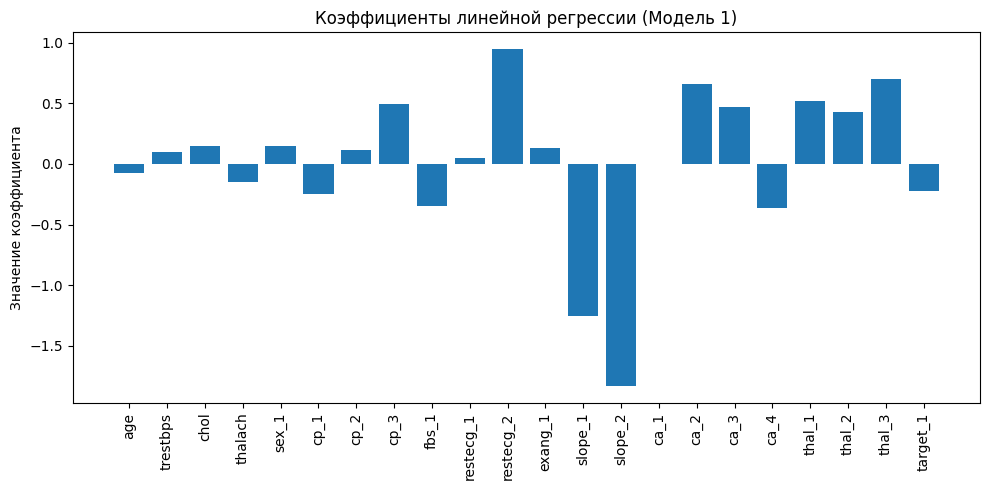

In [22]:
coefs = model1.coef_

plt.figure(figsize=(10, 5))
plt.bar(range(len(coefs)), coefs)
plt.xticks(range(len(coefs)), feature_names, rotation=90)
plt.title('Коэффициенты линейной регрессии (Модель 1)')
plt.ylabel('Значение коэффициента')
plt.tight_layout()
plt.show()

### По графику коэффициентов видно, что:

1) признаки с крупными положительными коэффициентами (cp_3, ca_2, thal_3 и т.п.) связаны с ростом oldpeak;

2) признаки с крупными отрицательными коэффициентами (slope_2, exang_1, cp_1, target_1) связаны со снижением предсказанного oldpeak;

3) по модулю коэффициента можно выбрать наиболее влияющие фичи и добавить их в best_features для следующих моделей (например, exang_1, slope_2, ca_2, thal_3).

# Модель 2

Train:
  MAE : 0.596
  MSE : 0.596
  RMSE: 0.772
  R²  : 0.508

Test:
  MAE : 0.849
  MSE : 1.188
  RMSE: 1.090
  R²  : 0.361



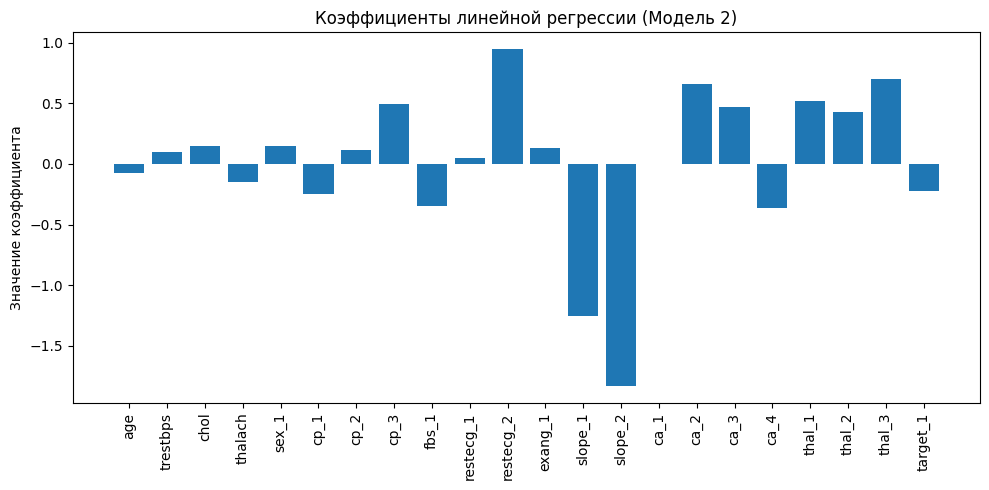

In [29]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. целевая и признаки
y = df['oldpeak']
X = df.drop('oldpeak', axis=1)

categorial_features = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']
numeric_features     = ['age','trestbps','chol','thalach']

# 2. OHE для категориальных
encoder = OneHotEncoder(sparse_output=False, drop='first')
X_cat = encoder.fit_transform(X[categorial_features])
cat_cols_ohe = encoder.get_feature_names_out(categorial_features)
X_cat = pd.DataFrame(X_cat, columns=cat_cols_ohe, index=X.index)

# 3. стандартизация числовых
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[numeric_features])
X_num_scaled = pd.DataFrame(X_num_scaled, columns=numeric_features, index=X.index)

# финальный X
X_final = pd.concat([X_num_scaled, X_cat], axis=1)
feature_names = X_final.columns

# 4. train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, shuffle=True
)

# 5. модель
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# 6. метрики
def print_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'{name}:')
    print(f'  MAE : {mae:.3f}')
    print(f'  MSE : {mse:.3f}')
    print(f'  RMSE: {rmse:.3f}')
    print(f'  R²  : {r2:.3f}\n')

print_metrics(y_train, y_pred_train, 'Train')
print_metrics(y_test,  y_pred_test,  'Test')

# 7. визуализация коэффициентов
coefs = model.coef_

plt.figure(figsize=(10, 5))
plt.bar(range(len(coefs)), coefs)
plt.xticks(range(len(coefs)), feature_names, rotation=90)
plt.title('Коэффициенты линейной регрессии (Модель 2)')
plt.ylabel('Значение коэффициента')
plt.tight_layout()
plt.show()


На train MAE ≈ 0.6 и RMSE ≈ 0.77: модель в среднем ошибается меньше чем на 1 единицу oldpeak, R² ≈ 0.51 — объясняет примерно половину вариации целевой, что можно считать средним качеством.

На test MAE ≈ 0.85 и RMSE ≈ 1.09, R² падает до ≈ 0.36: на новых данных ошибки ощутимо выше, но модель всё ещё улавливает часть зависимости; есть лёгкое переобучение, но не катастрофическое.

По графику коэффициентов видно, что признаки cp_3, ca_2, thal_3 (крупные положительные коэффициенты) связаны с ростом oldpeak, а slope_2, exang_1, cp_1, target_1 (крупные отрицательные) — со снижением, поэтому именно они выглядят наиболее важными кандидатами для best_features

Модель 3

MAE : 0.643
MSE : 0.716
RMSE: 0.846
R²  : 0.467


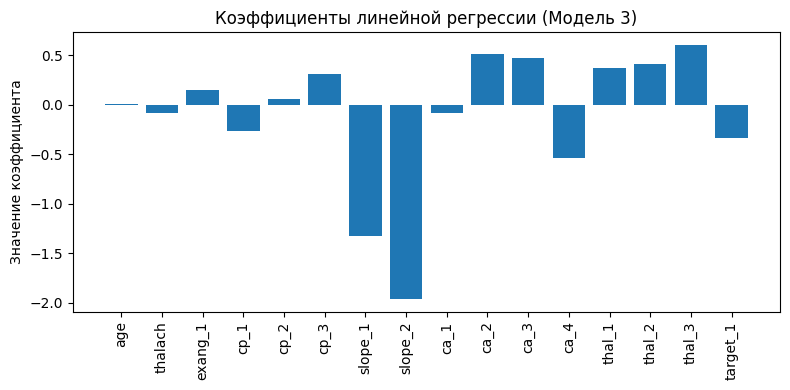

In [27]:
best_features = [
    'age',
    'thalach',
    'exang',
    'cp',
    'slope',
    'ca',
    'thal',
    'target'
]
numeric_best = ['age', 'thalach']
cat_best     = ['exang', 'cp', 'slope', 'ca', 'thal', 'target']

y = df['oldpeak']
X = df[best_features].copy()

encoder = OneHotEncoder(sparse_output=False, drop='first')
X_cat = encoder.fit_transform(X[cat_best])
cat_cols_ohe = encoder.get_feature_names_out(cat_best)
X_cat = pd.DataFrame(X_cat, columns=cat_cols_ohe, index=X.index)

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[numeric_best])
X_num_scaled = pd.DataFrame(X_num_scaled, columns=numeric_best, index=X.index)

X_final = pd.concat([X_num_scaled, X_cat], axis=1)
feature_names = X_final.columns
X_scaled = X_final.values

model3 = LinearRegression()
model3.fit(X_scaled, y)
y_pred2 = model3.predict(X_scaled)

mae  = mean_absolute_error(y, y_pred2)
mse  = mean_squared_error(y, y_pred2)
rmse = np.sqrt(mse)
r2   = r2_score(y, y_pred2)

print(f'MAE : {mae:.3f}')
print(f'MSE : {mse:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²  : {r2:.3f}')

coefs = model3.coef_

plt.figure(figsize=(8, 4))
plt.bar(range(len(coefs)), coefs)
plt.xticks(range(len(coefs)), feature_names, rotation=90)
plt.title('Коэффициенты линейной регрессии (Модель 3)')
plt.ylabel('Значение коэффициента')
plt.tight_layout()
plt.show()



По сравнению с моделью на всех признаках качество почти не ухудшилось: MAE вырос с ~0.60 до ~0.64, RMSE с ~0.77 до ~0.85, а R² снизился с ~0.51 до ~0.47, то есть объясняется всё ещё около 47% вариации oldpeak.

Это значит, что выбранные best_features содержат основную полезную информацию, а остальные признаки давали лишь небольшой прирост качества.

По графику коэффициентов видно, что сильное влияние на oldpeak оказывают slope_2 (крупный отрицательный коэффициент), а также положительные ca_2, ca_3, thal_3 и т.д.; рост этих признаков заметно повышает или понижает прогноз целевой

# Модель 4

Train (model4):
  MAE : 0.616
  MSE : 0.648
  RMSE: 0.805
  R²  : 0.465

Test  (model4):
  MAE : 0.775
  MSE : 1.017
  RMSE: 1.008
  R²  : 0.453



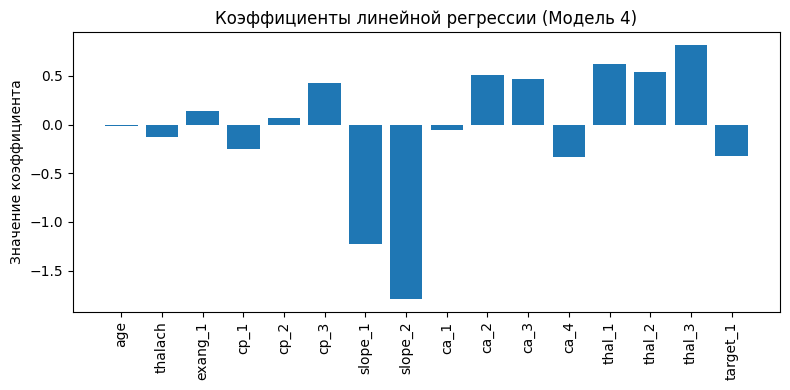

In [26]:
y = df['oldpeak']

best_features = [
    'age',
    'thalach',
    'exang',
    'cp',
    'slope',
    'ca',
    'thal',
    'target'
]

numeric_best = ['age', 'thalach']
cat_best     = ['exang', 'cp', 'slope', 'ca', 'thal', 'target']

X = df[best_features].copy()

encoder = OneHotEncoder(sparse_output=False, drop='first')
X_cat = encoder.fit_transform(X[cat_best])
cat_cols_ohe = encoder.get_feature_names_out(cat_best)
X_cat = pd.DataFrame(X_cat, columns=cat_cols_ohe, index=X.index)

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[numeric_best])
X_num_scaled = pd.DataFrame(X_num_scaled, columns=numeric_best, index=X.index)

X_final = pd.concat([X_num_scaled, X_cat], axis=1)
feature_names = X_final.columns

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, shuffle=True
)

model4 = LinearRegression()
model4.fit(X_train, y_train)

y_pred_train = model4.predict(X_train)
y_pred_test  = model4.predict(X_test)

def print_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'{name}:')
    print(f'  MAE : {mae:.3f}')
    print(f'  MSE : {mse:.3f}')
    print(f'  RMSE: {rmse:.3f}')
    print(f'  R²  : {r2:.3f}\n')

print_metrics(y_train, y_pred_train, 'Train (model4)')
print_metrics(y_test,  y_pred_test,  'Test  (model4)')

coefs = model4.coef_

plt.figure(figsize=(8, 4))
plt.bar(range(len(coefs)), coefs)
plt.xticks(range(len(coefs)), feature_names, rotation=90)
plt.title('Коэффициенты линейной регрессии (Модель 4)')
plt.ylabel('Значение коэффициента')
plt.tight_layout()
plt.show()

Train: MAE ≈ 0.62, RMSE ≈ 0.81, R² ≈ 0.47 – модель объясняет около 47% вариации oldpeak и в среднем ошибается меньше чем на 1 единицу по целевой.

Test: MAE ≈ 0.78, RMSE ≈ 1.01, R² ≈ 0.45 – качество на тесте очень близко к train, значит переобучение минимальное, а выбранные best_features хорошо обобщают зависимость.

По коэффициентам видно, что сильнее всего на oldpeak влияют отрицательные slope_2, slope_1 и положительные ca_2, ca_3, thal_3: рост этих категорий соответственно уменьшает или увеличивает прогноз целевой, остальные признаки влияют слабее.